# Compare author-annotated CTs with HRApop CTann annotations

This notebook compares the cell types (CTs) assigned by HRApop CT annotation tools against the author-provided CT for the **same `(dataset, cell)`**.

## Three complementary benchmark levels

The benchmark is reported at three levels so that broad global performance does not hide tissue- or cell-type-specific behavior:

1. **Cell-level exact agreement** — for each tool, compare the author and predicted Cell Ontology (CL) ID for the same biological cell. Coverage and exact agreement are reported separately.
2. **Organ-level performance** — repeat the benchmark independently within each organ, including organ-specific coverage and classification metrics.
3. **Organ × cell-type performance** — treat `(organ, CL ID)` as the evaluation class. This keeps the same CT in different organs separate (for example, `Lung × T cell` and `Liver × T cell`) and reports class-specific coverage, precision, recall, and F1.

### Main choices
- **Reference:** rows where `tool == "author"`
- **Prediction:** CellTypist, Azimuth, Pan-Human Azimuth, popV, and FR-Match rows
- **Primary correctness criterion:** exact equality of Cell Ontology IDs (`cell_id`), not label text
- **Matching key:** `(dataset, cell)` so that predictions are always compared with the author annotation for the same biological cell
- **Coverage and agreement are kept separate at all three levels**
- Dataset-level, confidence-bin, confusion, and common-cell analyses are retained as complementary diagnostics

> **Important:** exact CL-ID agreement is intentionally strict. A biologically compatible parent/child ontology relationship is still counted as a strict mismatch. Ontology-aware evaluation should be reported separately rather than silently changing the definition of exact agreement.


In [48]:
from pathlib import Path
import csv
import gzip
import collections
import math

# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
INPUT_FILE = Path("anatomogram-sc-transcriptomics-cell-instances.csv.gz")

if not INPUT_FILE.exists():
    file_path = Path("../anatomogram-data/anatomogram-sc-transcriptomics-cell-instances.csv.gz")
    if file_path.exists():
        INPUT_FILE = file_path

OUTPUT_DIR = Path("ctann_vs_author_results")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

ORG_NAMES = {
    "UBERON:0002107": "Liver",
    "UBERON:0001264": "Pancreas",
    "UBERON:0002113": "Kidney",
    "UBERON:0002048": "Lung",
}

TOOLS = ["celltypist", "azimuth", "pan-human-azimuth", "popv", "frmatch"]
MAJOR_TOOLS = ["celltypist", "azimuth", "pan-human-azimuth", "popv"]

print("Input:", INPUT_FILE.resolve())
print("Output directory:", OUTPUT_DIR.resolve())

Input: /Users/sbidanta/projects/HRA/Publication/hra-ftu-explorer-supporting-information/anatomogram-data/anatomogram-sc-transcriptomics-cell-instances.csv.gz
Output directory: /Users/sbidanta/projects/HRA/Publication/hra-ftu-explorer-supporting-information/anatomogram-comparison/ctann_vs_author_results


## 1. Load and reorganize the HRApop cell-instance table

The input is in long format: the same biological cell can have one `author` row and one row for each CTann tool. We reorganize it as:

```text
(dataset, cell) -> {tool_name: row}
```

Including `dataset` in the key prevents identical cell barcodes from different datasets from being accidentally merged.

If duplicate `(dataset, cell, tool)` rows occur, the code keeps the row with the higher confidence score and counts the duplicate.


In [49]:
def as_float(value):
    try:
        return float(value)
    except (TypeError, ValueError):
        return float("nan")


rec = collections.defaultdict(dict)
dups = collections.Counter()
rows_by_tool = collections.Counter()

with gzip.open(INPUT_FILE, "rt", newline="", encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)
    required = {"dataset", "organ", "tool", "cell", "cell_id", "cell_label", "match_type", "confidence_score"}
    missing = required - set(reader.fieldnames or [])
    if missing:
        raise ValueError(f"Missing required columns: {sorted(missing)}")

    for row in reader:
        key = (row["dataset"], row["cell"])
        tool = row["tool"]
        rows_by_tool[tool] += 1

        if tool in rec[key]:
            dups[tool] += 1
            new_conf = as_float(row["confidence_score"])
            old_conf = as_float(rec[key][tool]["confidence_score"])

            if (not math.isnan(new_conf)) and (math.isnan(old_conf) or new_conf > old_conf):
                rec[key][tool] = row
        else:
            rec[key][tool] = row

print(f"Unique (dataset, cell) keys: {len(rec):,}")
print("Rows by tool:", dict(rows_by_tool))
print("Duplicate dataset/cell/tool rows:", dict(dups))


Unique (dataset, cell) keys: 56,039
Rows by tool: {'celltypist': 23525, 'azimuth': 36991, 'pan-human-azimuth': 20893, 'author': 40285, 'popv': 23525, 'frmatch': 1925}
Duplicate dataset/cell/tool rows: {}


## 2. Metric function

For each tool we compare the author's `cell_id` with the tool's predicted `cell_id`.

- **Exact agreement** = fraction of overlapping cells with identical CL IDs
- **Macro precision / recall / F1** = unweighted average across CT classes present in author annotations
- **Weighted F1** = per-class F1 weighted by the number of author cells in each CT
- Confidence means are also reported separately for exact matches and mismatches.


In [50]:
def metrics_for(pairs):
    """Compute strict CL-ID classification metrics.

    Pair tuple layout:
      (author_id, predicted_id, confidence,
       author_label, predicted_label, match_type,
       organ_id, dataset, cell)
    """
    n = len(pairs)
    exact = sum(author_id == pred_id for author_id, pred_id, *_ in pairs)

    actual = collections.Counter(author_id for author_id, pred_id, *_ in pairs)
    predicted = collections.Counter(pred_id for author_id, pred_id, *_ in pairs)
    true_positive = collections.Counter(
        author_id
        for author_id, pred_id, *_ in pairs
        if author_id == pred_id
    )

    # Average over classes present in the author annotations.
    classes = sorted(actual)
    precisions = []
    recalls = []
    f1s = []
    weighted_f1_sum = 0.0

    for cell_type in classes:
        tp = true_positive[cell_type]
        precision = tp / predicted[cell_type] if predicted[cell_type] else 0.0
        recall = tp / actual[cell_type] if actual[cell_type] else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

        precisions.append(precision)
        recalls.append(recall)
        f1s.append(f1)
        weighted_f1_sum += f1 * actual[cell_type]

    conf_match = [
        as_float(x[2]) for x in pairs
        if x[0] == x[1] and not math.isnan(as_float(x[2]))
    ]
    conf_mismatch = [
        as_float(x[2]) for x in pairs
        if x[0] != x[1] and not math.isnan(as_float(x[2]))
    ]

    return {
        "overlap_cells": n,
        "exact_matches": exact,
        "mismatches": n - exact,
        "exact_agreement": exact / n if n else float("nan"),
        "macro_precision": sum(precisions) / len(precisions) if precisions else float("nan"),
        "macro_recall": sum(recalls) / len(recalls) if recalls else float("nan"),
        "macro_f1": sum(f1s) / len(f1s) if f1s else float("nan"),
        "weighted_f1": weighted_f1_sum / n if n else float("nan"),
        "author_classes": len(actual),
        "predicted_classes": len(predicted),
        "mean_conf_match": sum(conf_match) / len(conf_match) if conf_match else float("nan"),
        "mean_conf_mismatch": sum(conf_mismatch) / len(conf_mismatch) if conf_mismatch else float("nan"),
    }


## 3. Build author-vs-tool cell pairs

Only cells with an `author` annotation can be benchmarked. Missing predictions are **not** counted as errors; instead they affect tool coverage.


In [51]:
pairs_by_tool = collections.defaultdict(list)
pairs_by_tool_org = collections.defaultdict(list)
pairs_by_tool_dataset = collections.defaultdict(list)
mismatch_rows = []

all_author_cells = 0
all_author_with_any_prediction = 0
any_tool_exact_match = 0

for key, tool_map in rec.items():
    if "author" not in tool_map:
        continue

    all_author_cells += 1
    author = tool_map["author"]
    author_id = author["cell_id"]
    predictions = []

    for tool in TOOLS:
        if tool not in tool_map:
            continue

        pred = tool_map[tool]
        conf = as_float(pred["confidence_score"])

        item = (
            author_id,
            pred["cell_id"],
            conf,
            author["cell_label"],
            pred["cell_label"],
            pred["match_type"],
            author["organ"],
            author["dataset"],
            author["cell"],
        )

        pairs_by_tool[tool].append(item)
        pairs_by_tool_org[(tool, author["organ"])].append(item)
        pairs_by_tool_dataset[(tool, author["dataset"])].append(item)
        predictions.append((tool, pred["cell_id"], conf))

        if author_id != pred["cell_id"]:
            mismatch_rows.append({
                "dataset": author["dataset"],
                "organ_id": author["organ"],
                "organ": ORG_NAMES.get(author["organ"], author["organ"]),
                "cell": author["cell"],
                "tool": tool,
                "author_cell_id": author_id,
                "author_cell_label": author["cell_label"],
                "pred_cell_id": pred["cell_id"],
                "pred_cell_label": pred["cell_label"],
                "pred_match_type": pred["match_type"],
                "confidence_score": pred["confidence_score"],
            })

    if predictions:
        all_author_with_any_prediction += 1
        if any(pred_id == author_id for _, pred_id, _ in predictions):
            any_tool_exact_match += 1

print(f"Author cells: {all_author_cells:,}")
print(f"Author cells with >=1 CTann prediction: {all_author_with_any_prediction:,}")
print(f"Author cells with >=1 exact CTann match: {any_tool_exact_match:,}")


Author cells: 40,285
Author cells with >=1 CTann prediction: 40,285
Author cells with >=1 exact CTann match: 15,596


## 4. Level 1 — Cell-level exact agreement

This is the global cell-by-cell benchmark. `author_coverage` answers **how many author-annotated cells the tool can be compared on**. `exact_agreement` answers **among those overlapping cells, how often the CL ID is identical**.


In [52]:
summary = []

for tool in TOOLS:
    metrics = metrics_for(pairs_by_tool[tool])
    covered = metrics["overlap_cells"]

    summary.append({
        "tool": tool,
        "tool_rows": rows_by_tool[tool],
        "duplicate_cell_tool_rows": dups[tool],
        "author_cells_total": all_author_cells,
        "author_cells_with_tool": covered,
        "author_coverage": covered / all_author_cells if all_author_cells else float("nan"),
        **metrics,
    })

# Pretty display if pandas is available; otherwise print dictionaries.
try:
    import pandas as pd
    summary_df = pd.DataFrame(summary)
    display(summary_df)
except ImportError:
    summary_df = None
    for row in summary:
        print(row)


,tool,tool_rows,duplicate_cell_tool_rows,author_cells_total,author_cells_with_tool,author_coverage,overlap_cells,exact_matches,mismatches,exact_agreement,macro_precision,macro_recall,macro_f1,weighted_f1,author_classes,predicted_classes,mean_conf_match,mean_conf_mismatch
0,celltypist,23525,0,40285,20311,0.504183,20311,8839,11472,0.435183,0.338397,0.304801,0.287307,0.476746,35,61,0.856629,0.823420
1,azimuth,36991,0,40285,25285,0.627653,25285,5427,19858,0.214633,0.410374,0.371636,0.373289,0.220793,38,84,0.947069,0.894801
2,pan-human-azimuth,20893,0,40285,16330,0.405362,16330,2326,14004,0.142437,0.325474,0.227436,0.230173,0.149309,47,81,0.986045,0.884901
3,popv,23525,0,40285,20311,0.504183,20311,10384,9927,0.511250,0.433006,0.375464,0.371918,0.578677,35,51,0.866333,0.839579
4,frmatch,1925,0,40285,0,0.000000,0,0,0,NaN,NaN,NaN,NaN,NaN,0,0,NaN,NaN


## 5. Level 2 — Organ-level performance

The same exact-ID benchmark is repeated independently within each organ. In addition to agreement metrics, this level reports **organ-specific coverage**, because a tool may cover only a subset of the author-annotated cells in a tissue.


In [53]:
# Total number of author-annotated cells in each organ, independent of tool coverage.
author_cells_by_organ = collections.Counter()
for key, tool_map in rec.items():
    if "author" in tool_map:
        author_cells_by_organ[tool_map["author"]["organ"]] += 1

organ_summary = []

for tool in TOOLS:
    for organ_id in sorted(ORG_NAMES):
        pairs = pairs_by_tool_org[(tool, organ_id)]
        if not pairs:
            continue

        organ_total = author_cells_by_organ[organ_id]
        organ_metrics = metrics_for(pairs)
        covered = organ_metrics["overlap_cells"]

        organ_summary.append({
            "tool": tool,
            "organ_id": organ_id,
            "organ": ORG_NAMES[organ_id],
            "author_cells_total_organ": organ_total,
            "author_cells_with_tool_organ": covered,
            "organ_coverage": covered / organ_total if organ_total else float("nan"),
            **organ_metrics,
        })

try:
    organ_df = pd.DataFrame(organ_summary)
    display(organ_df)

    # Convenient organ x tool exact-agreement matrix.
    display(
        organ_df.pivot(index="organ", columns="tool", values="exact_agreement")
        .sort_index()
    )
except (NameError, ImportError):
    for row in organ_summary:
        print(row)


,tool,organ_id,organ,author_cells_total_organ,author_cells_with_tool_organ,organ_coverage,overlap_cells,exact_matches,mismatches,exact_agreement,macro_precision,macro_recall,macro_f1,weighted_f1,author_classes,predicted_classes,mean_conf_match,mean_conf_mismatch
0,celltypist,UBERON:0001264,Pancreas,2109,2109,1.000000,2109,1388,721,0.658132,0.203372,0.304145,0.232068,0.561689,13,4,0.569114,0.461894
1,celltypist,UBERON:0002048,Lung,3202,3202,1.000000,3202,928,2274,0.289819,0.411777,0.272201,0.285214,0.304916,13,45,0.932674,0.756863
2,celltypist,UBERON:0002107,Liver,15000,15000,1.000000,15000,6523,8477,0.434867,0.373518,0.324431,0.345293,0.492695,13,17,0.906989,0.872024
3,azimuth,UBERON:0001264,Pancreas,2109,2109,1.000000,2109,1847,262,0.875771,0.592091,0.577575,0.579904,0.863624,13,11,0.983880,0.974785
4,azimuth,UBERON:0002048,Lung,3202,3202,1.000000,3202,946,2256,0.295440,0.320104,0.232512,0.228792,0.316303,13,34,0.949134,0.960790
5,azimuth,UBERON:0002113,Kidney,19974,19974,1.000000,19974,2634,17340,0.131871,0.289807,0.278422,0.283693,0.137459,13,41,0.920514,0.885007
6,pan-human-azimuth,UBERON:0001264,Pancreas,2109,1268,0.601233,1268,764,504,0.602524,0.450666,0.404408,0.422294,0.629933,13,21,0.999999,0.999996
7,pan-human-azimuth,UBERON:0002048,Lung,3202,1862,0.581512,1862,390,1472,0.209452,0.262861,0.232325,0.237009,0.219661,13,48,0.969447,0.876258
8,pan-human-azimuth,UBERON:0002107,Liver,15000,9049,0.603267,9049,1094,7955,0.120897,0.323156,0.197704,0.209450,0.127090,12,50,0.988321,0.896121
9,pan-human-azimuth,UBERON:0002113,Kidney,19974,4151,0.207820,4151,78,4073,0.018791,0.300699,0.079954,0.091255,0.026910,13,25,0.900418,0.851869


tool,azimuth,celltypist,pan-human-azimuth,popv
organ,,,,
Kidney,0.131871,NaN,0.018791,NaN
Liver,NaN,0.434867,0.120897,0.471000
Lung,0.295440,0.289819,0.209452,0.489382
Pancreas,0.875771,0.658132,0.602524,0.830725


## 6. Level 3 — Organ × cell-type performance

A cell type can occur in several organs, and pooling those cells into one global CT class can hide tissue-specific behavior. Here the evaluation class is explicitly defined as:

```text
(organ, Cell Ontology ID)
```

For example, `Lung × T cell` and `Liver × T cell` are evaluated as separate classes.

For every tool and every author-defined organ–CT class, we report:

- **class coverage** — fraction of all author cells in that organ–CT class for which the tool has a prediction;
- **precision** — among cells predicted as that CT within that organ, the fraction whose author annotation is the same organ–CT class;
- **recall** — among covered author cells in that organ–CT class, the fraction assigned the exact same CL ID;
- **F1** — harmonic mean of precision and recall;
- **support** — the number of author cells in the class and the number available for the tool comparison.

The organ itself is not being predicted here; it is treated as known context for the cell. The CT prediction is evaluated within that organ.


In [54]:
# Build total author support for each (organ, CT) class before considering tool coverage.
author_class_total = collections.Counter()
author_class_label_counts = collections.defaultdict(collections.Counter)

for key, tool_map in rec.items():
    if "author" not in tool_map:
        continue
    author = tool_map["author"]
    class_key = (author["organ"], author["cell_id"])
    author_class_total[class_key] += 1
    author_class_label_counts[class_key][author["cell_label"]] += 1


def organ_celltype_metrics(tool, pairs):
    """Per-class metrics where the class is (organ, Cell Ontology ID)."""
    actual = collections.Counter()
    predicted = collections.Counter()
    true_positive = collections.Counter()

    for item in pairs:
        author_id, pred_id = item[0], item[1]
        organ_id = item[6]
        actual[(organ_id, author_id)] += 1
        predicted[(organ_id, pred_id)] += 1
        if author_id == pred_id:
            true_positive[(organ_id, author_id)] += 1

    rows = []
    for organ_id, author_id in sorted(actual):
        class_key = (organ_id, author_id)
        overlap_support = actual[class_key]
        total_support = author_class_total[class_key]
        predicted_as_class = predicted[class_key]
        tp = true_positive[class_key]
        fp = predicted_as_class - tp
        fn = overlap_support - tp

        precision = tp / predicted_as_class if predicted_as_class else 0.0
        recall = tp / overlap_support if overlap_support else 0.0
        f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0

        label_counts = author_class_label_counts[class_key]
        author_label = label_counts.most_common(1)[0][0] if label_counts else ""

        rows.append({
            "tool": tool,
            "organ_id": organ_id,
            "organ": ORG_NAMES.get(organ_id, organ_id),
            "author_cell_id": author_id,
            "author_cell_label": author_label,
            "author_cells_total_for_class": total_support,
            "author_cells_with_tool_for_class": overlap_support,
            "class_coverage": overlap_support / total_support if total_support else float("nan"),
            "predicted_as_class": predicted_as_class,
            "true_positive": tp,
            "false_positive": fp,
            "false_negative": fn,
            "precision": precision,
            "recall": recall,
            "f1": f1,
        })

    return rows


organ_celltype_summary = []
for tool in TOOLS:
    organ_celltype_summary.extend(organ_celltype_metrics(tool, pairs_by_tool[tool]))

try:
    organ_ct_df = pd.DataFrame(organ_celltype_summary)
    display(organ_ct_df)

    # A compact view of the most highly supported organ–CT classes.
    top_supported = (
        organ_ct_df[organ_ct_df["tool"].isin(MAJOR_TOOLS)]
        .sort_values(["author_cells_total_for_class", "tool"], ascending=[False, True])
        [[
            "tool", "organ", "author_cell_label", "author_cell_id",
            "author_cells_total_for_class", "author_cells_with_tool_for_class",
            "class_coverage", "precision", "recall", "f1"
        ]]
        .head(40)
    )
    display(top_supported)
except (NameError, ImportError):
    for row in organ_celltype_summary[:40]:
        print(row)


,tool,organ_id,organ,author_cell_id,author_cell_label,author_cells_total_for_class,author_cells_with_tool_for_class,class_coverage,predicted_as_class,true_positive,false_positive,false_negative,precision,recall,f1
0,celltypist,UBERON:0001264,Pancreas,ASCTB-TEMP:co-expression-cell,co-expression cell,36,36,1.0,0,0,0,36,0.000000,0.000000,0.000000
1,celltypist,UBERON:0001264,Pancreas,CL:0000097,mast cell,7,7,1.0,0,0,0,7,0.000000,0.000000,0.000000
2,celltypist,UBERON:0001264,Pancreas,CL:0000115,endothelial cell,15,15,1.0,0,0,0,15,0.000000,0.000000,0.000000
3,celltypist,UBERON:0001264,Pancreas,CL:0000145,professional antigen presenting cell,4,4,1.0,0,0,0,4,0.000000,0.000000,0.000000
4,celltypist,UBERON:0001264,Pancreas,CL:0000169,type B pancreatic cell,257,257,1.0,323,251,72,6,0.777090,0.976654,0.865517
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
163,popv,UBERON:0002107,Liver,CL:0000236,B cell,405,405,1.0,0,0,0,405,0.000000,0.000000,0.000000
164,popv,UBERON:0002107,Liver,CL:0000623,natural killer cell,919,919,1.0,0,0,0,919,0.000000,0.000000,0.000000
165,popv,UBERON:0002107,Liver,CL:0000786,plasma cell,164,164,1.0,435,139,296,25,0.319540,0.847561,0.464107
166,popv,UBERON:0002107,Liver,CL:1000398,endothelial cell of hepatic sinusoid,2337,2337,1.0,2213,2168,45,169,0.979666,0.927685,0.952967


,tool,organ,author_cell_label,author_cell_id,author_cells_total_for_class,author_cells_with_tool_for_class,class_coverage,precision,recall,f1
30,celltypist,Liver,T cell,CL:0000084,7676,7676,1.000000,0.880267,0.653205,0.749925
107,pan-human-azimuth,Liver,T cell,CL:0000084,7676,3857,0.502475,0.750000,0.000778,0.001554
159,popv,Liver,T cell,CL:0000084,7676,7676,1.000000,0.920386,0.497004,0.645461
70,azimuth,Kidney,epithelial cell of proximal tubule,CL:0002306,5481,5481,1.000000,0.000000,0.000000,0.000000
121,pan-human-azimuth,Kidney,epithelial cell of proximal tubule,CL:0002306,5481,2153,0.392812,1.000000,0.010683,0.021140
77,azimuth,Kidney,kidney loop of Henle thick ascending limb epit...,CL:1001106,4431,4431,1.000000,0.000000,0.000000,0.000000
128,pan-human-azimuth,Kidney,kidney loop of Henle thick ascending limb epit...,CL:1001106,4431,848,0.191379,0.000000,0.000000,0.000000
75,azimuth,Kidney,kidney distal convoluted tubule epithelial cell,CL:1000849,3249,3249,1.000000,0.000000,0.000000,0.000000
126,pan-human-azimuth,Kidney,kidney distal convoluted tubule epithelial cell,CL:1000849,3249,178,0.054786,0.000000,0.000000,0.000000
37,celltypist,Liver,endothelial cell of hepatic sinusoid,CL:1000398,2337,2337,1.000000,0.000000,0.000000,0.000000


## 7. Dataset-level summary


In [55]:
dataset_summary = []

for (tool, dataset), pairs in sorted(pairs_by_tool_dataset.items()):
    organ_id = pairs[0][6] if pairs else ""

    dataset_summary.append({
        "tool": tool,
        "dataset": dataset,
        "organ_id": organ_id,
        "organ": ORG_NAMES.get(organ_id, organ_id),
        **metrics_for(pairs),
    })

try:
    dataset_df = pd.DataFrame(dataset_summary)
    display(dataset_df)
except (NameError, ImportError):
    for row in dataset_summary[:20]:
        print(row)


,tool,dataset,organ_id,organ,overlap_cells,exact_matches,mismatches,exact_agreement,macro_precision,macro_recall,macro_f1,weighted_f1,author_classes,predicted_classes,mean_conf_match,mean_conf_mismatch
0,azimuth,https://www.ebi.ac.uk/gxa/sc/experiments/E-CUR...,UBERON:0002113,Kidney,4114,675,3439,0.164074,0.293351,0.288636,0.290762,0.166968,13,27,0.876728,0.890328
1,azimuth,https://www.ebi.ac.uk/gxa/sc/experiments/E-CUR...,UBERON:0002113,Kidney,2919,267,2652,0.091470,0.290362,0.258379,0.271196,0.102777,13,30,0.957159,0.917187
2,azimuth,https://www.ebi.ac.uk/gxa/sc/experiments/E-CUR...,UBERON:0002113,Kidney,5456,792,4664,0.145161,0.287626,0.275701,0.280149,0.155955,13,33,0.916438,0.881021
3,azimuth,https://www.ebi.ac.uk/gxa/sc/experiments/E-CUR...,UBERON:0002113,Kidney,3682,236,3446,0.064096,0.284493,0.268190,0.275352,0.067177,13,28,0.981639,0.868624
4,azimuth,https://www.ebi.ac.uk/gxa/sc/experiments/E-CUR...,UBERON:0002113,Kidney,3803,664,3139,0.174599,0.289684,0.285600,0.287098,0.170627,13,34,0.933428,0.875896
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
75,popv,https://www.ebi.ac.uk/gxa/sc/experiments/E-MTA...,UBERON:0001264,Pancreas,213,186,27,0.873239,0.491690,0.541523,0.513942,0.823253,11,7,0.940860,0.753086
76,popv,https://www.ebi.ac.uk/gxa/sc/experiments/E-MTA...,UBERON:0001264,Pancreas,248,225,23,0.907258,0.447648,0.542857,0.478354,0.878683,11,7,0.929630,0.688406
77,popv,https://www.ebi.ac.uk/gxa/sc/experiments/E-MTA...,UBERON:0001264,Pancreas,275,229,46,0.832727,0.535971,0.562500,0.546563,0.802328,12,10,0.979622,0.768116
78,popv,https://www.ebi.ac.uk/gxa/sc/experiments/E-MTA...,UBERON:0001264,Pancreas,279,246,33,0.881720,0.508132,0.537190,0.521398,0.851530,11,8,0.986450,0.772727


## 8. Top author → CTann confusion pairs

This counts the most frequent strict CL-ID disagreements for each tool. These pairs are useful for spotting ontology granularity issues such as a broad author term versus a more specific CTann term.


In [56]:
confusion_counts = collections.Counter()
label_lookup = {}

for tool, pairs in pairs_by_tool.items():
    for author_id, pred_id, conf, author_label, pred_label, *_ in pairs:
        if author_id != pred_id:
            confusion_counts[(tool, author_id, pred_id)] += 1
            label_lookup[(tool, author_id, pred_id)] = (author_label, pred_label)

confusion_rows = []

for tool in TOOLS:
    tool_confusions = [
        (count, author_id, pred_id)
        for (this_tool, author_id, pred_id), count in confusion_counts.items()
        if this_tool == tool
    ]
    tool_confusions.sort(reverse=True)

    for rank, (count, author_id, pred_id) in enumerate(tool_confusions[:25], 1):
        author_label, pred_label = label_lookup[(tool, author_id, pred_id)]
        confusion_rows.append({
            "tool": tool,
            "rank": rank,
            "count": count,
            "author_cell_id": author_id,
            "author_cell_label": author_label,
            "pred_cell_id": pred_id,
            "pred_cell_label": pred_label,
        })

try:
    confusion_df = pd.DataFrame(confusion_rows)
    display(confusion_df)
except (NameError, ImportError):
    for row in confusion_rows:
        print(row)


,tool,rank,count,author_cell_id,author_cell_label,pred_cell_id,pred_cell_label
0,celltypist,1,2251,CL:1000398,endothelial cell of hepatic sinusoid,CL:0000115,Endothelial cells
1,celltypist,2,1418,CL:0000084,T cell,CL:4047101,Resident NK
2,celltypist,3,1148,CL:0000084,T cell,CL:0000814,Circulating NK/NKT
3,celltypist,4,859,CL:0000235,macrophage,CL:0000763,Mono+mono derived cells
4,celltypist,5,706,CL:1001603,lung macrophage,CL:0000583,Alveolar macrophages
...,...,...,...,...,...,...,...
95,popv,21,62,CL:0000084,T cell,CL:0000625,"CD8-positive, alpha-beta T cell"
96,popv,22,57,CL:1000398,endothelial cell of hepatic sinusoid,CL:0000814,mature NK T cell
97,popv,23,55,CL:1000398,endothelial cell of hepatic sinusoid,CL:0000235,macrophage
98,popv,24,54,ASCTB-TEMP:cycling-cell,cycling cell,CL:0000814,mature NK T cell


## 9. Confidence-bin analysis

This asks whether higher-confidence CTann calls are more likely to exactly match the author CL ID.


In [57]:
CONFIDENCE_BINS = [
    (0.0, 0.5, "[0,0.5)"),
    (0.5, 0.7, "[0.5,0.7)"),
    (0.7, 0.8, "[0.7,0.8)"),
    (0.8, 0.9, "[0.8,0.9)"),
    (0.9, 0.95, "[0.9,0.95)"),
    (0.95, 1.0000001, "[0.95,1]"),
]

confidence_summary = []

for tool in TOOLS:
    pairs = pairs_by_tool[tool]

    for low, high, label in CONFIDENCE_BINS:
        subset = [
            x for x in pairs
            if not math.isnan(x[2]) and low <= x[2] < high
        ]

        if not subset:
            continue

        confidence_summary.append({
            "tool": tool,
            "confidence_bin": label,
            **metrics_for(subset),
        })

try:
    confidence_df = pd.DataFrame(confidence_summary)
    display(confidence_df)
except (NameError, ImportError):
    for row in confidence_summary:
        print(row)


,tool,confidence_bin,overlap_cells,exact_matches,mismatches,exact_agreement,macro_precision,macro_recall,macro_f1,weighted_f1,author_classes,predicted_classes,mean_conf_match,mean_conf_mismatch
0,celltypist,"[0,0.5)",3033,1143,1890,0.376855,0.230014,0.187369,0.168933,0.410541,32,56,0.188125,0.201246
1,celltypist,"[0.5,0.7)",986,380,606,0.385396,0.350075,0.246078,0.253943,0.442098,28,46,0.605249,0.603405
2,celltypist,"[0.7,0.8)",660,265,395,0.401515,0.430468,0.283761,0.300518,0.449033,27,39,0.755605,0.755375
3,celltypist,"[0.8,0.9)",1098,425,673,0.387067,0.346875,0.262316,0.246913,0.441169,30,43,0.857546,0.854173
4,celltypist,"[0.9,0.95)",1003,419,584,0.417747,0.435951,0.343652,0.338416,0.471357,27,43,0.929674,0.927731
5,celltypist,"[0.95,1]",13531,6207,7324,0.458724,0.367933,0.327662,0.314029,0.502055,34,53,0.994441,0.994707
6,azimuth,"[0,0.5)",49,8,41,0.163265,0.090909,0.090909,0.090909,0.163265,11,11,0.452382,0.424934
7,azimuth,"[0.5,0.7)",860,115,745,0.133721,0.248738,0.319333,0.271088,0.127766,20,34,0.624813,0.638216
8,azimuth,"[0.7,0.8)",2185,159,2026,0.072769,0.230869,0.308012,0.250526,0.070167,24,34,0.756208,0.761372
9,azimuth,"[0.8,0.9)",6717,656,6061,0.097663,0.285579,0.291051,0.267532,0.100237,34,55,0.863320,0.856750


## 10. Fair head-to-head comparison on common cells

Overall tool metrics can involve different cell populations because tool coverage differs. This section restricts the benchmark to cells having **author + all four major CTann outputs** so every tool is evaluated on exactly the same cells.


In [58]:
common_keys = []

for key, tool_map in rec.items():
    if "author" in tool_map and all(tool in tool_map for tool in MAJOR_TOOLS):
        common_keys.append(key)

common_summary = []

for tool in MAJOR_TOOLS:
    pairs = []
    for key in common_keys:
        tool_map = rec[key]
        author = tool_map["author"]
        pred = tool_map[tool]
        pairs.append((
            author["cell_id"],
            pred["cell_id"],
            as_float(pred["confidence_score"]),
            author["cell_label"],
            pred["cell_label"],
            pred["match_type"],
            author["organ"],
            author["dataset"],
            author["cell"],
        ))

    common_summary.append({"tool": tool, **metrics_for(pairs)})

print(f"Common author + all-major-tools cells: {len(common_keys):,}")
try:
    common_df = pd.DataFrame(common_summary)
    display(common_df)
except (NameError, ImportError):
    for row in common_summary:
        print(row)


Common author + all-major-tools cells: 3,130


,tool,overlap_cells,exact_matches,mismatches,exact_agreement,macro_precision,macro_recall,macro_f1,weighted_f1,author_classes,predicted_classes,mean_conf_match,mean_conf_mismatch
0,celltypist,3130,1160,1970,0.370607,0.284633,0.289002,0.238080,0.338204,25,47,0.694783,0.689997
1,azimuth,3130,1445,1685,0.461661,0.449371,0.409389,0.398403,0.475801,25,44,0.980488,0.964849
2,pan-human-azimuth,3130,1154,1976,0.368690,0.331043,0.291106,0.302844,0.385867,25,62,0.989674,0.907819
3,popv,3130,1706,1424,0.545048,0.445942,0.385156,0.379547,0.554234,25,43,0.963755,0.800679


## 11. Write all benchmark outputs

The notebook writes the same core result files used in the comparison, plus a common-cell summary.


In [59]:
def write_csv(path, rows, fields=None):
    if fields is None:
        fields = list(rows[0].keys()) if rows else []

    with open(path, "w", newline="", encoding="utf-8") as f:
        writer = csv.DictWriter(f, fieldnames=fields)
        writer.writeheader()
        writer.writerows(rows)


# Three primary benchmark levels.
write_csv(OUTPUT_DIR / "level1_cell_level_by_tool.csv", summary)
write_csv(OUTPUT_DIR / "level2_organ_level_by_tool.csv", organ_summary)
write_csv(OUTPUT_DIR / "level3_organ_celltype_level.csv", organ_celltype_summary)

# Backward-compatible and complementary diagnostic outputs.
write_csv(OUTPUT_DIR / "ctann_vs_author_summary.csv", summary)
write_csv(OUTPUT_DIR / "ctann_vs_author_by_organ.csv", organ_summary)
write_csv(OUTPUT_DIR / "ctann_vs_author_by_organ_celltype.csv", organ_celltype_summary)
write_csv(OUTPUT_DIR / "ctann_vs_author_by_dataset.csv", dataset_summary)
write_csv(OUTPUT_DIR / "ctann_vs_author_top_confusions.csv", confusion_rows)
write_csv(OUTPUT_DIR / "ctann_vs_author_confidence_bins.csv", confidence_summary)
write_csv(OUTPUT_DIR / "ctann_vs_author_common_cells.csv", common_summary)

with gzip.open(
    OUTPUT_DIR / "ctann_vs_author_mismatches.csv.gz",
    "wt",
    newline="",
    encoding="utf-8",
) as f:
    fields = list(mismatch_rows[0].keys()) if mismatch_rows else []
    writer = csv.DictWriter(f, fieldnames=fields)
    writer.writeheader()
    writer.writerows(mismatch_rows)

print("Wrote:")
for path in sorted(OUTPUT_DIR.iterdir()):
    print(" -", path)


Wrote:
 - ctann_vs_author_results/ctann_vs_author_by_dataset.csv
 - ctann_vs_author_results/ctann_vs_author_by_organ.csv
 - ctann_vs_author_results/ctann_vs_author_by_organ_celltype.csv
 - ctann_vs_author_results/ctann_vs_author_common_cells.csv
 - ctann_vs_author_results/ctann_vs_author_confidence_bins.csv
 - ctann_vs_author_results/ctann_vs_author_mismatches.csv.gz
 - ctann_vs_author_results/ctann_vs_author_summary.csv
 - ctann_vs_author_results/ctann_vs_author_top_confusions.csv
 - ctann_vs_author_results/level1_cell_level_by_tool.csv
 - ctann_vs_author_results/level2_organ_level_by_tool.csv
 - ctann_vs_author_results/level3_organ_celltype_level.csv


## 12. Important interpretation note: ontology-aware evaluation

The strict benchmark above counts different CL IDs as a mismatch even if one term is a parent or child of the other. For example, a broad author annotation such as a proximal-tubule epithelial cell and a segment-specific Azimuth prediction may be biologically compatible.

A stronger next step is to use the Cell Ontology graph and classify each pair as:

```text
EXACT
NARROWER_THAN_AUTHOR
BROADER_THAN_AUTHOR
RELATED
UNRELATED
```

That ontology-aware evaluation should be analyzed separately from strict exact-ID agreement rather than silently changing the definition of accuracy.


## 13. Meaningful visualizations

The plots below are aligned with the three primary benchmark levels and the complementary diagnostics:

1. **Level 1 — coverage vs exact agreement:** global cell-level performance.
2. **Level 2 — organ × tool heatmap:** tissue-specific exact agreement.
3. **Level 3 — organ × cell-type F1 heatmap:** performance for the same CT in its organ context.
4. **Common-cell head-to-head:** direct comparison on exactly the same cells.
5. **Confidence vs agreement:** calibration-style diagnostic.
6. **Top author → prediction confusions:** dominant strict-ID disagreements.

All figures use the strict Cell Ontology ID benchmark. Ontology parent/child relationships therefore remain strict mismatches.


In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# A consistent display order and readable names.
TOOL_ORDER = ["celltypist", "azimuth", "pan-human-azimuth", "popv"]
TOOL_LABELS = {
    "celltypist": "CellTypist",
    "azimuth": "Azimuth",
    "pan-human-azimuth": "Pan-Human Azimuth",
    "popv": "popV",
    "frmatch": "FR-Match",
}

FIGURE_DIR = OUTPUT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Notebook-friendly defaults. No explicit color palette is imposed.
plt.rcParams.update({
    "figure.figsize": (9, 5.5),
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
})

print("Figures will be written to:", FIGURE_DIR.resolve())


Figures will be written to: /Users/sbidanta/projects/HRA/Publication/hra-ftu-explorer-supporting-information/anatomogram-comparison/ctann_vs_author_results/figures


### 13.1 Level 1: Coverage versus exact agreement

This plot prevents a common benchmarking mistake: comparing accuracy without considering how many author-annotated cells a tool actually covers. A strong method should ideally appear high on **both** measures.


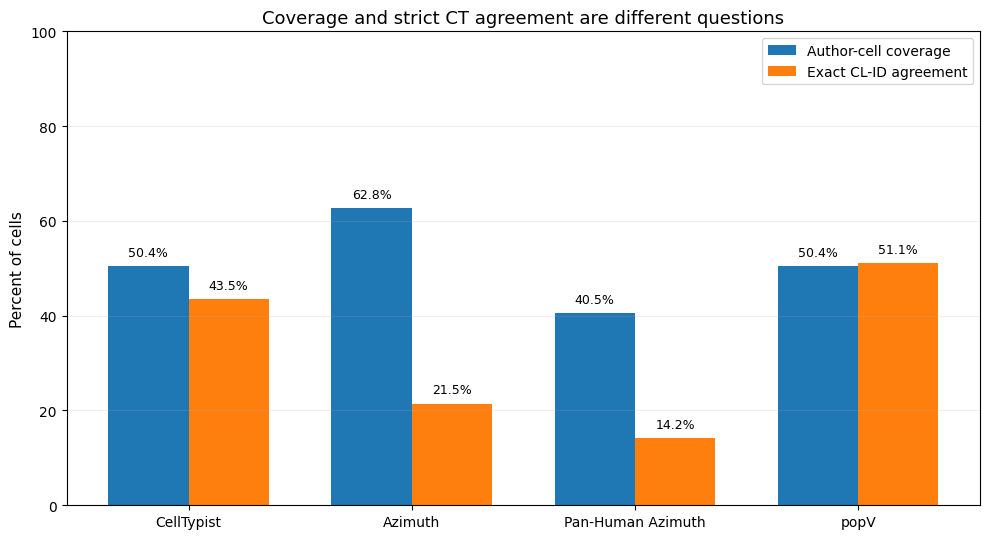

In [61]:
plot_df = (
    summary_df[summary_df["tool"].isin(TOOL_ORDER)]
    .set_index("tool")
    .reindex(TOOL_ORDER)
    .reset_index()
)

x = np.arange(len(plot_df))
width = 0.36

fig, ax = plt.subplots(figsize=(10, 5.5))
coverage_bars = ax.bar(
    x - width / 2,
    100 * plot_df["author_coverage"],
    width,
    label="Author-cell coverage",
)
agreement_bars = ax.bar(
    x + width / 2,
    100 * plot_df["exact_agreement"],
    width,
    label="Exact CL-ID agreement",
)

ax.set_ylabel("Percent of cells")
ax.set_title("Coverage and strict CT agreement are different questions")
ax.set_xticks(x, [TOOL_LABELS[t] for t in plot_df["tool"]])
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis="y", alpha=0.2)

for bars in (coverage_bars, agreement_bars):
    for bar in bars:
        value = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            value + 1.5,
            f"{value:.1f}%",
            ha="center",
            va="bottom",
            fontsize=9,
        )

fig.tight_layout()
fig.savefig(FIGURE_DIR / "01_coverage_vs_exact_agreement.png", dpi=180, bbox_inches="tight")
plt.show()


### 13.2 Level 2: Organ × tool exact-agreement heatmap

This is the most important diagnostic visualization for this benchmark. It exposes tissue specificity that disappears in an overall average. Blank cells mean that no overlapping author/tool annotations were available for that organ.


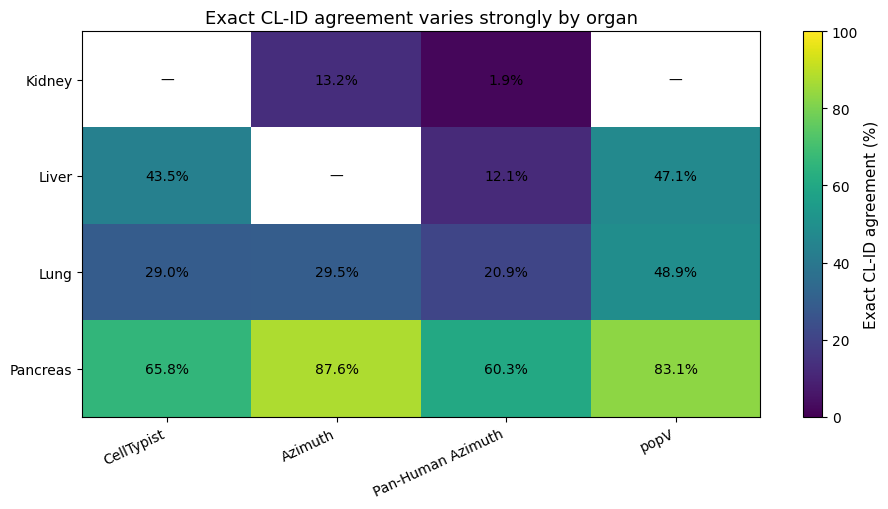

In [62]:
organ_matrix = (
    organ_df[organ_df["tool"].isin(TOOL_ORDER)]
    .pivot(index="organ", columns="tool", values="exact_agreement")
    .reindex(columns=TOOL_ORDER)
)

# Keep a biologically intuitive stable order when present.
organ_order = [o for o in ["Kidney", "Liver", "Lung", "Pancreas"] if o in organ_matrix.index]
organ_matrix = organ_matrix.reindex(organ_order)

values = 100 * organ_matrix.to_numpy(dtype=float)
masked = np.ma.masked_invalid(values)

fig, ax = plt.subplots(figsize=(9.5, 5.2))
im = ax.imshow(masked, aspect="auto", vmin=0, vmax=100)

ax.set_xticks(np.arange(len(organ_matrix.columns)))
ax.set_xticklabels([TOOL_LABELS[t] for t in organ_matrix.columns], rotation=25, ha="right")
ax.set_yticks(np.arange(len(organ_matrix.index)))
ax.set_yticklabels(organ_matrix.index)
ax.set_title("Exact CL-ID agreement varies strongly by organ")

for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        val = values[i, j]
        if np.isfinite(val):
            # Let matplotlib use standard text rendering; add a compact cell label.
            ax.text(j, i, f"{val:.1f}%", ha="center", va="center", fontsize=10)
        else:
            ax.text(j, i, "—", ha="center", va="center", fontsize=10)

cbar = fig.colorbar(im, ax=ax)
cbar.set_label("Exact CL-ID agreement (%)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "02_organ_tool_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()


### 13.3 Level 3: Organ × cell-type F1 heatmap

This view keeps the organ context attached to each CT. Rows represent `organ × author CT` classes and columns represent CTann tools. To keep the figure readable, the heatmap shows the most highly supported author organ–CT classes; the complete class-level results are written to CSV.

F1 is used here because it penalizes both failure to recover an author CT (false negatives) and over-assignment of that CT to cells belonging to other author classes within the same organ (false positives).


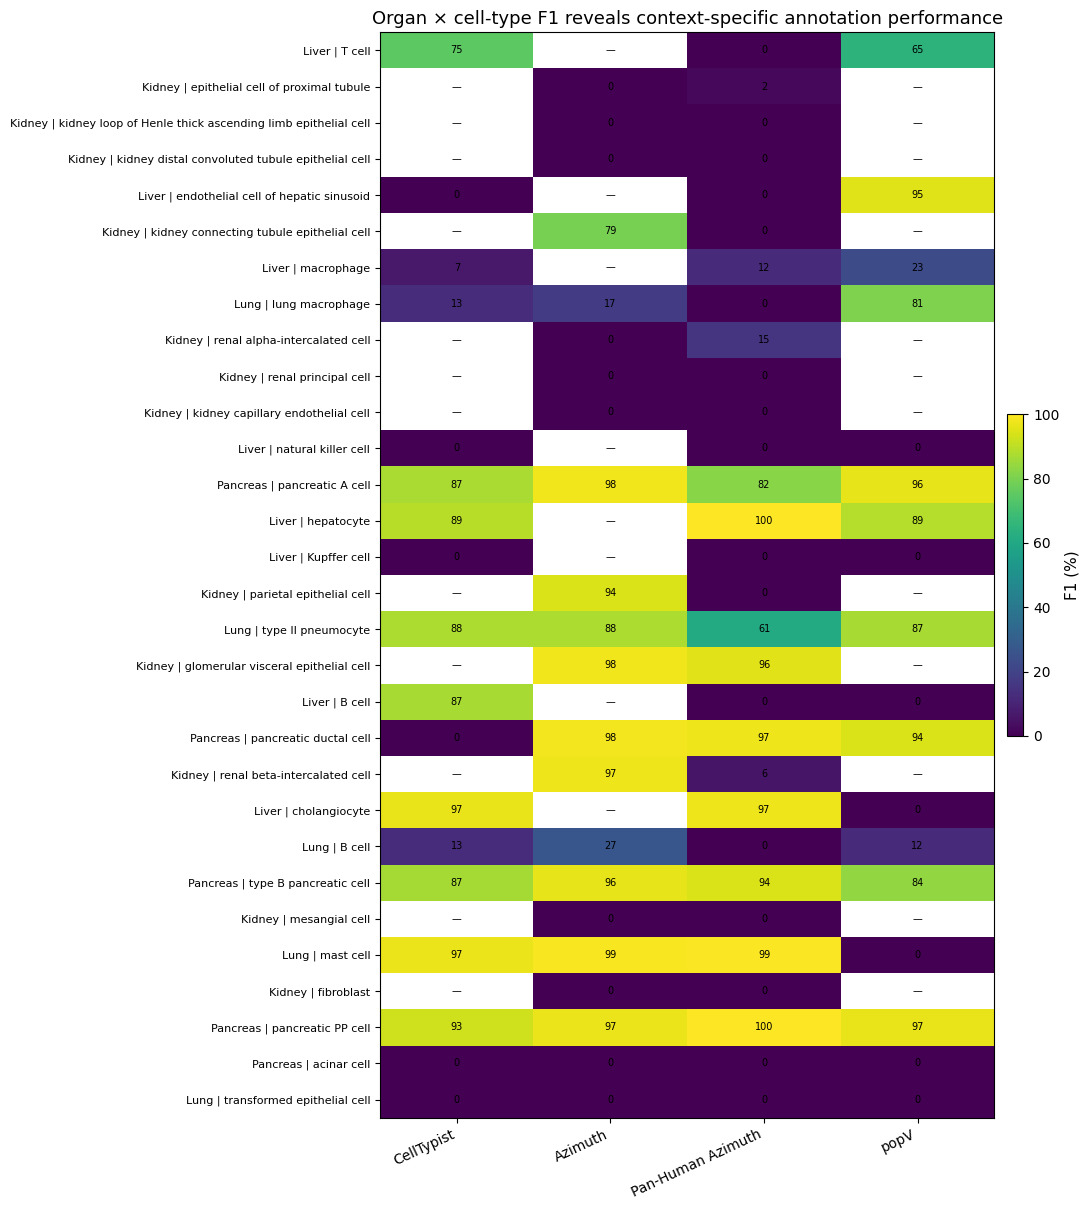

In [63]:
# Select highly supported organ–CT classes for a readable cross-tool heatmap.
# The full, unfiltered class-level table remains available in the CSV output.
MIN_CLASS_SUPPORT = 25
TOP_ORGAN_CT_CLASSES = 30

level3_plot_df = organ_ct_df[organ_ct_df["tool"].isin(TOOL_ORDER)].copy()

class_support = (
    level3_plot_df[["organ", "author_cell_id", "author_cell_label", "author_cells_total_for_class"]]
    .drop_duplicates()
)
class_support = class_support[class_support["author_cells_total_for_class"] >= MIN_CLASS_SUPPORT]
class_support = class_support.sort_values("author_cells_total_for_class", ascending=False).head(TOP_ORGAN_CT_CLASSES)

selected_keys = set(zip(class_support["organ"], class_support["author_cell_id"]))
plot_rows = level3_plot_df[
    [(organ, ct) in selected_keys for organ, ct in zip(level3_plot_df["organ"], level3_plot_df["author_cell_id"])]
].copy()

plot_rows["organ_ct"] = plot_rows["organ"] + " | " + plot_rows["author_cell_label"]

# Preserve support-ranked row order.
row_order = [
    f"{r.organ} | {r.author_cell_label}"
    for r in class_support.itertuples(index=False)
]
row_order = list(dict.fromkeys(row_order))

f1_matrix = (
    plot_rows.pivot_table(index="organ_ct", columns="tool", values="f1", aggfunc="first")
    .reindex(index=row_order, columns=TOOL_ORDER)
)

values = 100 * f1_matrix.to_numpy(dtype=float)
masked = np.ma.masked_invalid(values)

fig_height = max(8, 0.34 * len(f1_matrix.index) + 2)
fig, ax = plt.subplots(figsize=(11, fig_height))
im = ax.imshow(masked, aspect="auto", vmin=0, vmax=100)

ax.set_xticks(np.arange(len(f1_matrix.columns)))
ax.set_xticklabels([TOOL_LABELS[t] for t in f1_matrix.columns], rotation=25, ha="right")
ax.set_yticks(np.arange(len(f1_matrix.index)))
ax.set_yticklabels(f1_matrix.index, fontsize=8)
ax.set_title("Organ × cell-type F1 reveals context-specific annotation performance")

for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        val = values[i, j]
        if np.isfinite(val):
            ax.text(j, i, f"{val:.0f}", ha="center", va="center", fontsize=7)
        else:
            ax.text(j, i, "—", ha="center", va="center", fontsize=7)

cbar = fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02)
cbar.set_label("F1 (%)")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "03_organ_celltype_f1_heatmap.png", dpi=180, bbox_inches="tight")
plt.show()


### 13.4 Fair head-to-head comparison on common cells

Overall scores use different overlapping cell populations. This chart removes that coverage confound by restricting evaluation to the cells annotated by the author **and all four major CTann tools**.


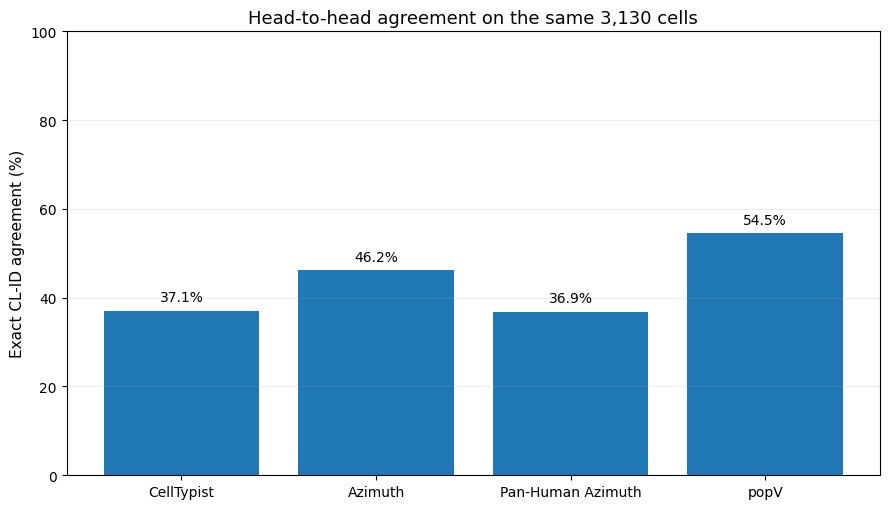

In [64]:
common_plot = (
    common_df[common_df["tool"].isin(TOOL_ORDER)]
    .set_index("tool")
    .reindex(TOOL_ORDER)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(9, 5.2))
bars = ax.bar(
    [TOOL_LABELS[t] for t in common_plot["tool"]],
    100 * common_plot["exact_agreement"],
)

ax.set_ylabel("Exact CL-ID agreement (%)")
ax.set_ylim(0, 100)
ax.set_title(f"Head-to-head agreement on the same {int(common_plot['overlap_cells'].iloc[0]):,} cells")
ax.grid(axis="y", alpha=0.2)

for bar, value in zip(bars, 100 * common_plot["exact_agreement"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        value + 1.5,
        f"{value:.1f}%",
        ha="center",
        va="bottom",
        fontsize=10,
    )

fig.tight_layout()
fig.savefig(FIGURE_DIR / "04_common_cell_head_to_head.png", dpi=180, bbox_inches="tight")
plt.show()


### 13.5 Confidence versus exact agreement

This plot checks whether higher model confidence corresponds to greater author agreement. The point labels give the number of cells in each confidence bin, which is important because a high rate based on only a few cells can be misleading.


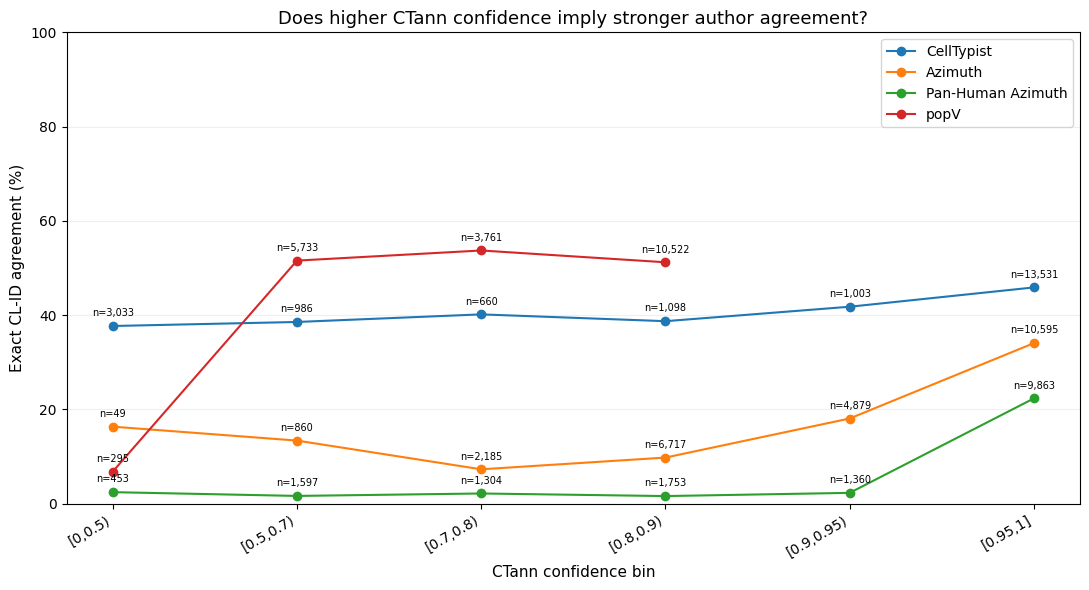

In [65]:
bin_order = [label for _, _, label in CONFIDENCE_BINS]
conf_plot = confidence_df[confidence_df["tool"].isin(TOOL_ORDER)].copy()
conf_plot["confidence_bin"] = pd.Categorical(
    conf_plot["confidence_bin"], categories=bin_order, ordered=True
)

fig, ax = plt.subplots(figsize=(11, 6))

for tool in TOOL_ORDER:
    d = conf_plot[conf_plot["tool"] == tool].sort_values("confidence_bin")
    if d.empty:
        continue
    x = np.arange(len(d))
    y = 100 * d["exact_agreement"].to_numpy()
    ax.plot(x, y, marker="o", label=TOOL_LABELS[tool])

    for xi, yi, n in zip(x, y, d["overlap_cells"]):
        ax.annotate(
            f"n={int(n):,}",
            (xi, yi),
            xytext=(0, 7),
            textcoords="offset points",
            ha="center",
            fontsize=7,
        )

ax.set_xticks(np.arange(len(bin_order)))
ax.set_xticklabels(bin_order, rotation=30, ha="right")
ax.set_xlabel("CTann confidence bin")
ax.set_ylabel("Exact CL-ID agreement (%)")
ax.set_ylim(0, 100)
ax.set_title("Does higher CTann confidence imply stronger author agreement?")
ax.legend()
ax.grid(axis="y", alpha=0.2)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "05_confidence_vs_agreement.png", dpi=180, bbox_inches="tight")
plt.show()


### 13.6 Dominant author → CTann confusions

A single accuracy number does not explain *why* a tool disagrees. These ranked charts show the most frequent mismatch pairs. Large bars can reveal systematic granularity differences, synonym/ontology mapping issues, or biologically important confusion patterns.

A separate figure is drawn for each tool to keep the long CT labels readable.


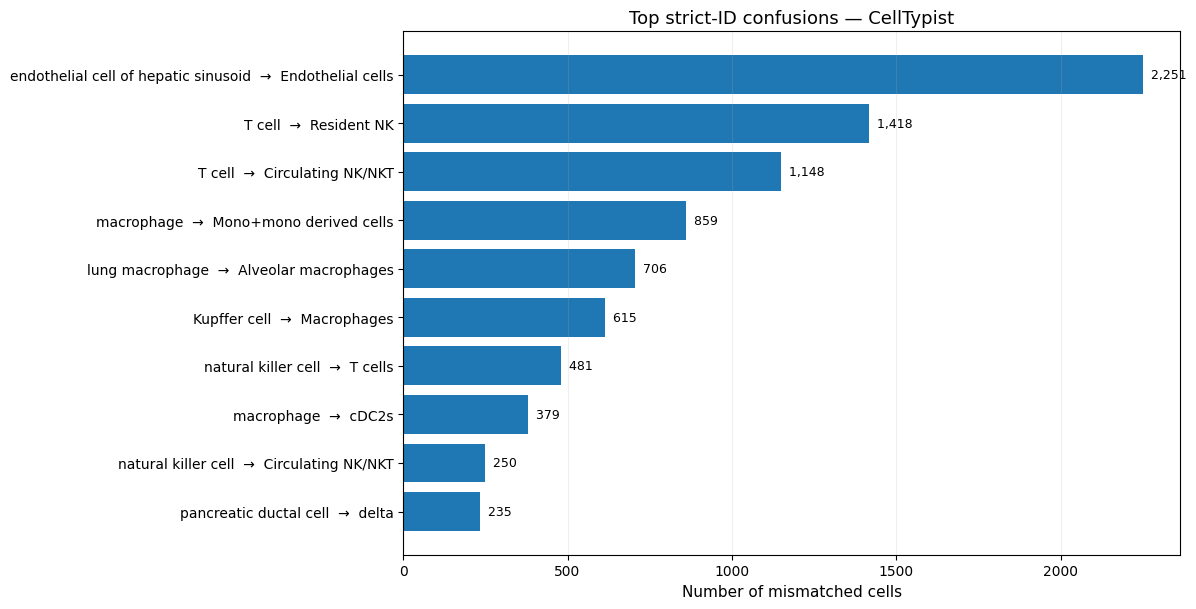

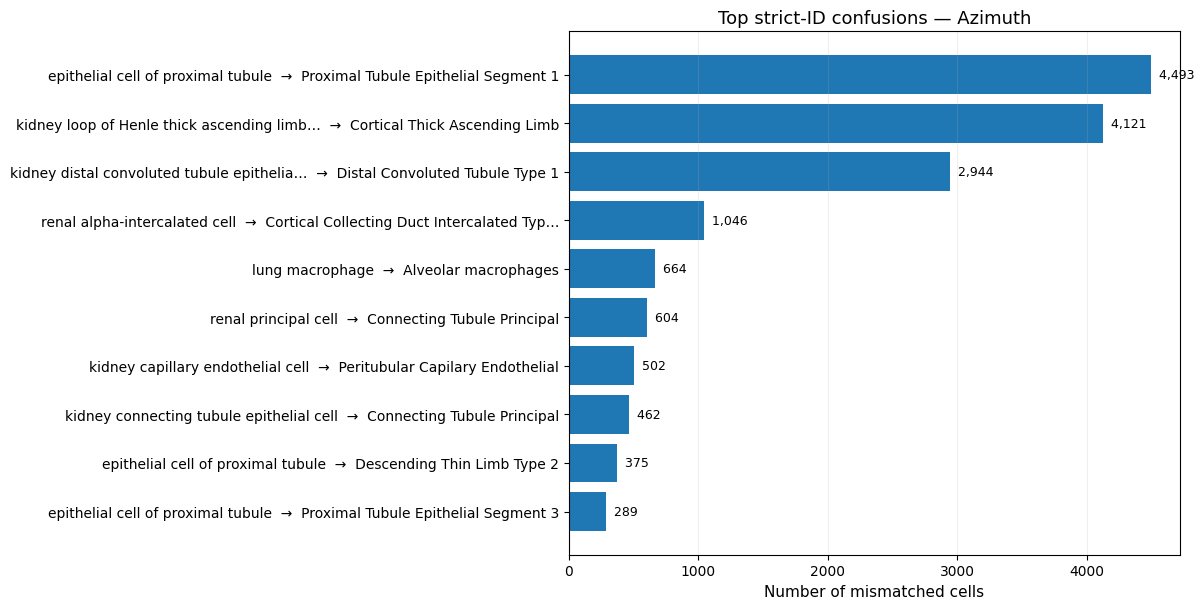

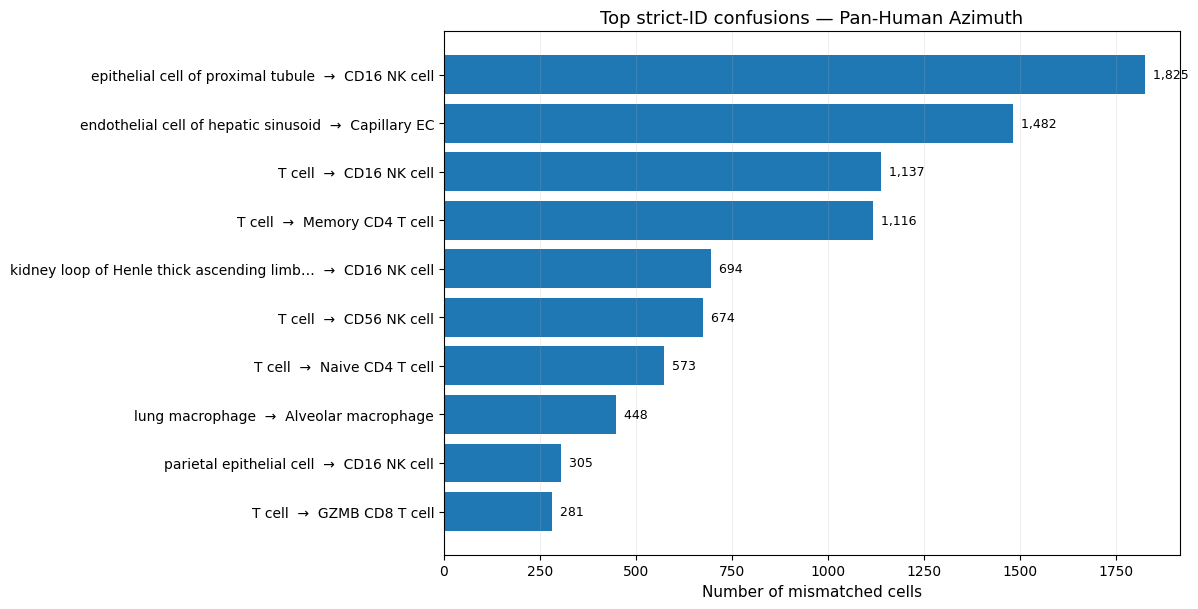

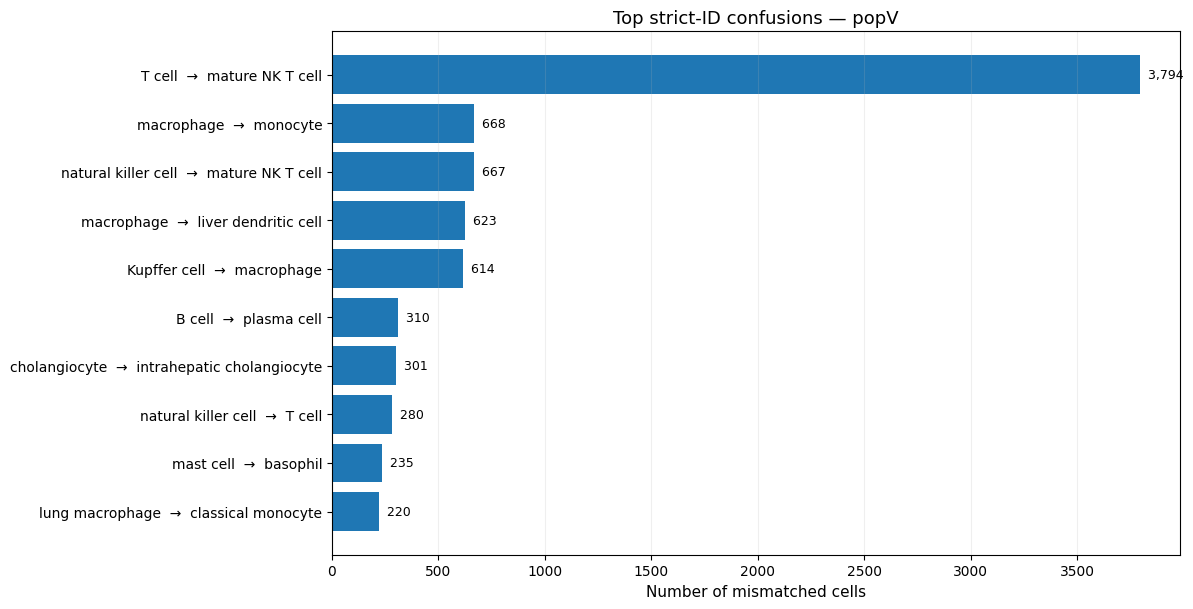

In [66]:
TOP_N = 10

for tool in TOOL_ORDER:
    d = (
        confusion_df[confusion_df["tool"] == tool]
        .sort_values(["count", "rank"], ascending=[False, True])
        .head(TOP_N)
        .copy()
    )
    if d.empty:
        continue

    # Shorten very long labels while preserving both sides of the confusion.
    def shorten(text, n=42):
        text = str(text)
        return text if len(text) <= n else text[: n - 1] + "…"

    d["pair"] = [
        f"{shorten(a)}  →  {shorten(p)}"
        for a, p in zip(d["author_cell_label"], d["pred_cell_label"])
    ]
    d = d.sort_values("count", ascending=True)

    fig, ax = plt.subplots(figsize=(12, 6.2))
    bars = ax.barh(d["pair"], d["count"])
    ax.set_xlabel("Number of mismatched cells")
    ax.set_title(f"Top strict-ID confusions — {TOOL_LABELS[tool]}")
    ax.grid(axis="x", alpha=0.2)

    for bar, count in zip(bars, d["count"]):
        ax.text(
            count,
            bar.get_y() + bar.get_height() / 2,
            f"  {int(count):,}",
            va="center",
            fontsize=9,
        )

    fig.tight_layout()
    safe_tool = tool.replace("-", "_")
    fig.savefig(
        FIGURE_DIR / f"06_top_confusions_{safe_tool}.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()
